In [1]:
import numpy as np
import matplotlib.pyplot as plt

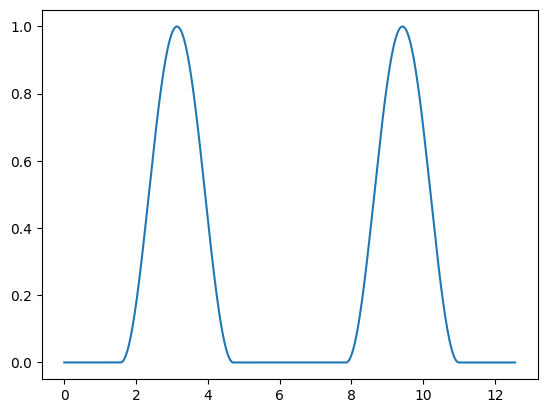

In [2]:
x = np.linspace(0, 4 * np.pi, 1000)


def f(x):
    angle = x % (2 * np.pi) - np.pi
    duty_ratio = 0.5
    if duty_ratio < 1:
        angle *= 0.5 / (1 - duty_ratio)
    y = 0.5 * (np.cos(2.0 * np.clip(angle, -np.pi / 2, np.pi / 2)) + 1.0)
    return y

y = [f(x) for x in x]

plt.plot(x, y)
plt.show()

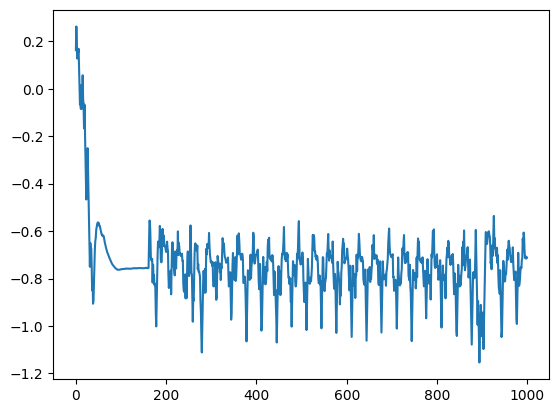

In [6]:
data = np.load("h1_data.npz")
q_buffer = data["q"]
qd_buffer = data["qd"]
ctrl_buffer = data["ctrl"]

# go through ctrl, clip single change maximum to 0.5
for i in range(1, ctrl_buffer.shape[0]):
    ctrl_buffer[i] = np.clip(ctrl_buffer[i], ctrl_buffer[i-1] - 0.1, ctrl_buffer[i-1] + 0.1)

plt.plot(ctrl_buffer[:, 2])
plt.show()